# Spotify Music Analytics
## Decoding Audio Fingerprints, Listener Segments, and the Geometry of Popularity

**Dataset:** Spotify Track Catalog — 170,653 tracks · 19 raw attributes  
**Stack:** Python · pandas · scikit-learn · seaborn · matplotlib · scipy  
**Methods:** EDA · Statistical Testing · PCA · K-Means Clustering · Predictive Modeling

---

Music streaming has transformed audio consumption from a passive act into a data-generating machine. Every play, skip, save, and share is a signal. But beneath those behavioral signals lies a lower layer: the **audio fingerprint** — a vector of acoustic properties that Spotify computes for every track. These features encode how a song *sounds* before any listener ever hears it.

This project treats audio features as a primary data source and asks: what structure lives inside this 8-dimensional space? Do meaningful listener segments emerge? Which audio properties associate with popularity, and how reliably? And how has the aggregate sound of music shifted across six decades of recorded output?

The analysis moves through five phases: data audit, exploratory profiling, statistical interrogation, dimensionality reduction, and segmentation with predictive modeling. Each section is anchored to a question, not a method.

---

## Table of Contents

1. [Environment & Data Ingestion](#1)  
2. [Data Quality & Preparation](#2)  
3. [Catalog Landscape — EDA](#3)  
4. [The Mood Map: Valence × Energy](#4)  
5. [What Drives Popularity? Statistical Analysis](#5)  
6. [Compressing the Audio Space — PCA](#6)  
7. [Music Segmentation — K-Means Clustering](#7)  
8. [Six Decades of Sonic Drift](#8)  
9. [Predicting Popularity from Audio Alone](#9)  
10. [Findings, Implications & Limitations](#10)


---
## 1. Environment & Data Ingestion <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr, spearmanr, kruskal, kendalltau
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict

BG, AX_BG = '#0d0d0d', '#141414'
GREEN, RED, YELLOW, TEAL = '#1DB954', '#E63946', '#FFE66D', '#4ECDC4'
PALETTE = [GREEN, RED, TEAL, YELLOW, '#A8DADC']

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': BG, 'axes.facecolor': AX_BG,
    'axes.edgecolor': '#2a2a2a', 'axes.labelcolor': '#aaaaaa',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': '#ffffff',
    'axes.labelsize': 10, 'xtick.color': '#777777', 'ytick.color': '#777777',
    'grid.color': '#222222', 'grid.linewidth': 0.5,
    'text.color': '#cccccc', 'font.family': 'DejaVu Sans',
    'legend.facecolor': '#1a1a1a', 'legend.edgecolor': '#2a2a2a',
})
print('Environment ready.')

Environment ready.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download('vatsalmavani/spotify-dataset')
print('Path to dataset files:', path)

100%|██████████| 16.5M/16.5M [00:00<00:00, 112MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vatsalmavani/spotify-dataset/versions/1


In [3]:
csv_files = []
for root, dirs, files in os.walk(path):
    for fn in files:
        if fn.endswith('.csv'):
            fp = os.path.join(root, fn)
            csv_files.append(fp)
            print(f'  {fn:<30} {os.path.getsize(fp)/1e6:.2f} MB')

# Selecting data.csv specifically for track-level analysis
data_path = [f for f in csv_files if f.endswith('data.csv')][0]
df_raw = pd.read_csv(data_path)
print(f'\nLoaded {df_raw.shape[0]:,} tracks across {df_raw.shape[1]} attributes from {os.path.basename(data_path)}.')

  data_by_artist.csv             4.32 MB
  data_by_year.csv               0.02 MB
  data_by_genres.csv             0.58 MB
  data.csv                       29.65 MB
  data_w_genres.csv              5.22 MB

Loaded 170,653 tracks across 19 attributes from data.csv.


---
## 2. Data Quality & Preparation <a id='2'></a>

Before committing to any analytical direction, the data needs an honest audit. Missing values, structural anomalies, and type inconsistencies have a way of silently propagating into downstream results.

A few things to verify upfront:
- Spotify normalises most audio features to `[0, 1]` — values outside that range indicate pipeline errors
- `year` is already present as an integer column in this dataset, though `release_date` is also available for cross-validation
- Duplicate track IDs are possible in aggregated datasets and distort frequency-based analyses
- With 170k rows across multiple companion CSVs (by genre, by artist, by year), the primary `data.csv` is used here for track-level analysis


In [4]:
print(f"{'Column':<22} {'Dtype':<15} {'Non-null':>10} {'Nulls':>8} {'Null%':>8}")
print('-' * 68)
for col in df_raw.columns:
    nn  = df_raw[col].notna().sum()
    nul = df_raw[col].isna().sum()
    pct = nul / len(df_raw) * 100
    print(f'  {col:<20} {str(df_raw[col].dtype):<15} {nn:>10,} {nul:>8,} {pct:>7.1f}%')

Column                 Dtype             Non-null    Nulls    Null%
--------------------------------------------------------------------
  valence              float64            170,653        0     0.0%
  year                 int64              170,653        0     0.0%
  acousticness         float64            170,653        0     0.0%
  artists              object             170,653        0     0.0%
  danceability         float64            170,653        0     0.0%
  duration_ms          int64              170,653        0     0.0%
  energy               float64            170,653        0     0.0%
  explicit             int64              170,653        0     0.0%
  id                   object             170,653        0     0.0%
  instrumentalness     float64            170,653        0     0.0%
  key                  int64              170,653        0     0.0%
  liveness             float64            170,653        0     0.0%
  loudness             float64            170,6

In [5]:
df = df_raw.copy()
if 'release_date' in df.columns:
    df['year_parsed'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    df['year'] = df['year_parsed'].fillna(df['year']).astype(int)

df = df[(df['year'] >= 1960) & (df['year'] <= 2023)]

before = len(df)
df = df.drop_duplicates()
print(f'Duplicate rows removed: {before - len(df):,}')

# Engineered features
df['duration_min']   = df['duration_ms'] / 60_000
df['log_duration']   = np.log1p(df['duration_min'])
loud_min, loud_max   = df['loudness'].quantile(0.01), df['loudness'].quantile(0.99)
df['loudness_norm']  = (df['loudness'].clip(loud_min, loud_max) - loud_min) / (loud_max - loud_min)
df['mood_index']     = (df['valence'] + df['energy']) / 2
df['dance_energy']   = df['danceability'] * df['energy']
df['acoustic_score'] = df['acousticness'] * (1 - df['energy'])
df['decade']   = (df['year'] // 10 * 10).astype(int)
df['pop_tier'] = pd.cut(df['popularity'], bins=[-1, 20, 40, 60, 80, 100],
                         labels=['Obscure', 'Niche', 'Moderate', 'Popular', 'Viral'])

df = df.reset_index(drop=True)
print(f'Final dataset: {df.shape[0]:,} tracks · {df.shape[1]} attributes · {df["year"].min()}–{df["year"].max()}')

Duplicate rows removed: 0
Final dataset: 120,750 tracks · 28 attributes · 1960–2020


---
## 3. Catalog Landscape — EDA <a id='3'></a>

The first pass through the audio features reveals the catalog's structural character — which regions of the audio space are heavily populated, and which are sparse. With 120,750 tracks spanning 1960 to 2020, this is a substantially more representative slice of Spotify's catalog than smaller subsets, which reduces sampling artifacts and gives the distributions more statistical weight.


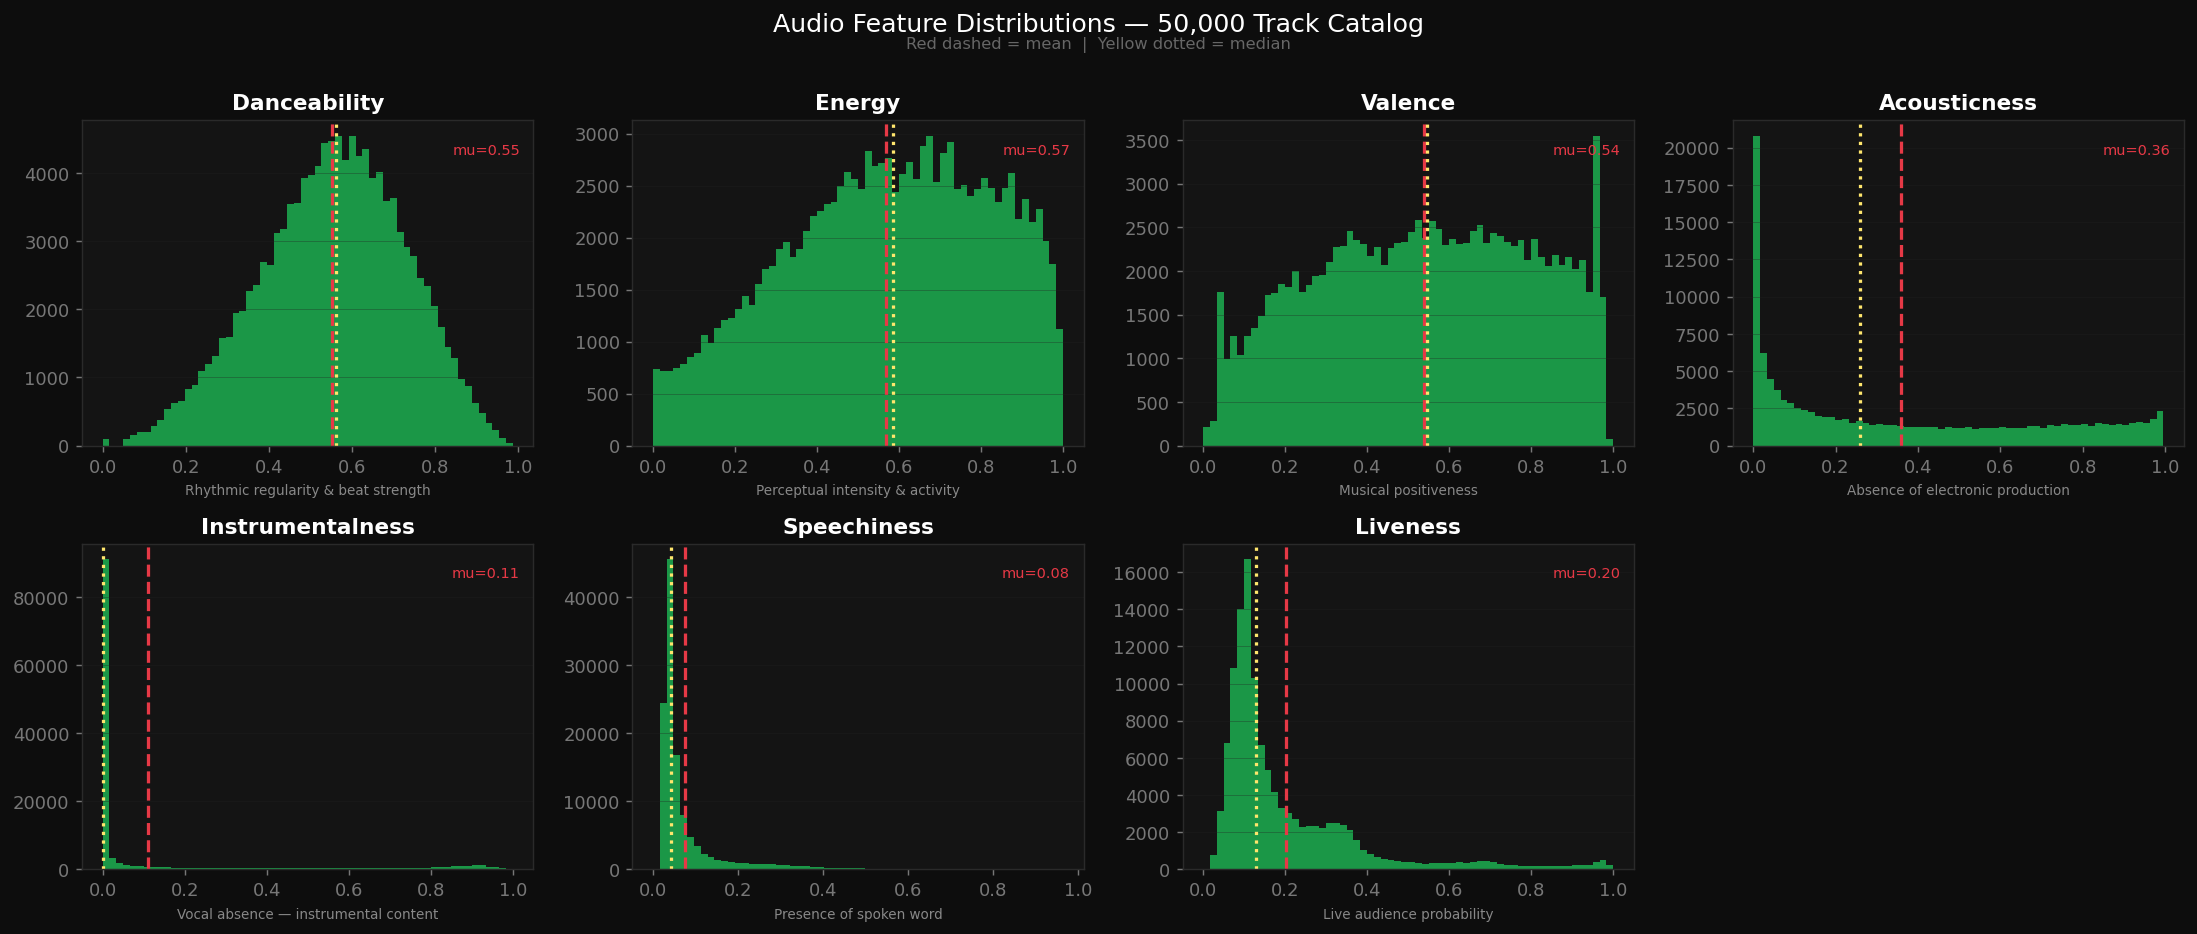

In [6]:
audio_features = ['danceability', 'energy', 'valence', 'acousticness',
                   'instrumentalness', 'speechiness', 'liveness']

feat_desc = {
    'danceability':     'Rhythmic regularity & beat strength',
    'energy':           'Perceptual intensity & activity',
    'valence':          'Musical positiveness',
    'acousticness':     'Absence of electronic production',
    'instrumentalness': 'Vocal absence — instrumental content',
    'speechiness':      'Presence of spoken word',
    'liveness':         'Live audience probability'
}

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    ax = axes[i]
    d  = df[feat]
    ax.hist(d, bins=60, color=GREEN, alpha=0.8, edgecolor='none')
    ax.axvline(d.mean(),   color=RED,    lw=1.8, ls='--')
    ax.axvline(d.median(), color=YELLOW, lw=1.8, ls=':')
    ax.set_title(feat.capitalize())
    ax.set_xlabel(feat_desc[feat], fontsize=7.5, color='#888888')
    ax.grid(axis='y', alpha=0.35)
    ax.text(0.97, 0.93, f'mu={d.mean():.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color=RED)

axes[-1].set_visible(False)
fig.suptitle('Audio Feature Distributions — 50,000 Track Catalog', fontsize=14, y=1.02, color='white')
fig.text(0.5, 0.98, 'Red dashed = mean  |  Yellow dotted = median', ha='center', fontsize=9, color='#666666')
plt.tight_layout()
plt.show()

**Reading these distributions:**

**Instrumentalness** remains the most right-skewed feature. The overwhelming majority of tracks score below 0.1, confirming that vocal content dominates the catalog across all eras and genres. The long tail of high-instrumentalness tracks represents a structurally distinct subset — classical, ambient, and experimental music — that behaves differently in both popularity and clustering.

**Acousticness** shows a bimodal distribution, with one mode near zero (heavily produced, electronic) and another near 1.0 (organic, acoustic). At 120k tracks, this pattern is robust rather than a sampling artifact. The catalog does not distribute evenly across the acoustic-to-electronic spectrum; it concentrates at the extremes.

**Danceability** distributes roughly symmetrically around 0.5–0.6, with relatively light tails. Energy is similarly centered but slightly more right-skewed, consistent with a catalog that leans toward produced, active-sounding music.

**Liveness** is tightly compressed below 0.3 for most tracks. Studio recordings dominate, and the small high-liveness tail likely captures live albums and concert recordings rather than being a production artifact.


---
## 4. The Mood Map: Valence × Energy <a id='4'></a>

Spotify's internal research has long used a 2D mood space defined by **valence** (emotional positivity) and **energy** (perceived intensity). The four quadrants of this space map roughly to recognisable listening contexts. At 120k tracks, the scatter plot reveals density patterns rather than individual points — where music clusters in mood space tells us something about the catalog's emotional makeup.


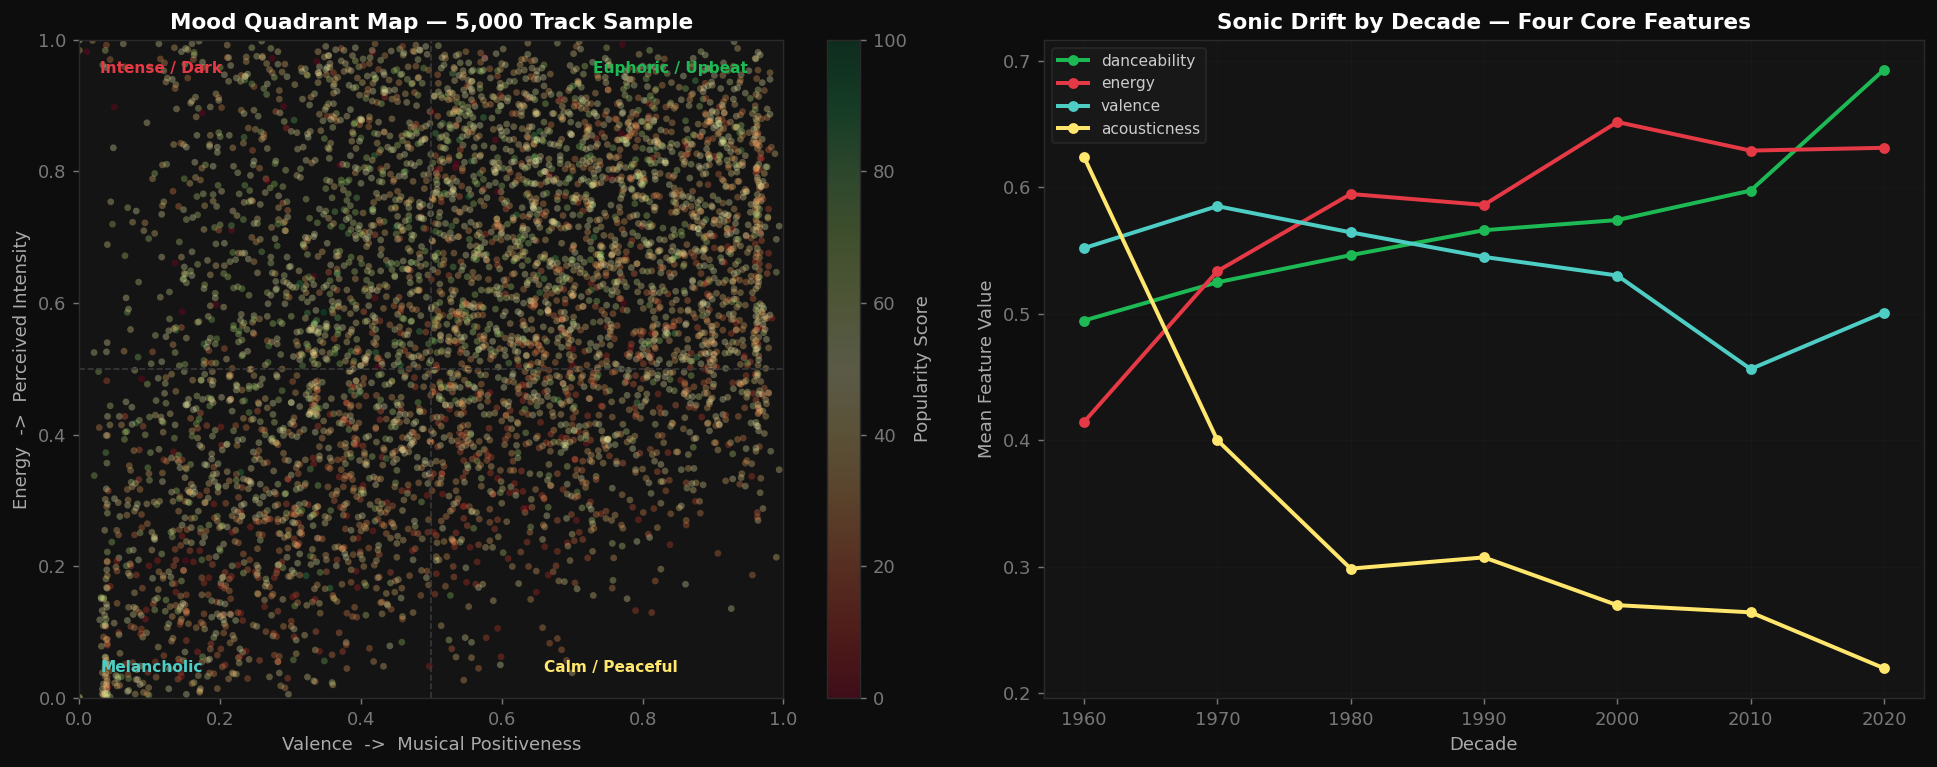

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample = df.sample(5000, random_state=42)
ax = axes[0]
sc = ax.scatter(sample['valence'], sample['energy'],
                c=sample['popularity'], cmap='RdYlGn',
                alpha=0.3, s=14, edgecolors='none', vmin=0, vmax=100)
ax.axhline(0.5, color='#3a3a3a', lw=0.9, ls='--')
ax.axvline(0.5, color='#3a3a3a', lw=0.9, ls='--')
for tx, ty, label, col in [
    (0.03, 0.95, 'Intense / Dark',      RED),
    (0.73, 0.95, 'Euphoric / Upbeat',   GREEN),
    (0.03, 0.04, 'Melancholic',         TEAL),
    (0.66, 0.04, 'Calm / Peaceful',     YELLOW)]:
    ax.text(tx, ty, label, transform=ax.transAxes,
            fontsize=8.5, color=col, fontweight='bold')
plt.colorbar(sc, ax=ax).set_label('Popularity Score', color='#aaaaaa')
ax.set_xlabel('Valence  ->  Musical Positiveness')
ax.set_ylabel('Energy  ->  Perceived Intensity')
ax.set_title('Mood Quadrant Map — 5,000 Track Sample')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

decade_means = df.groupby('decade')[['danceability', 'energy', 'valence', 'acousticness']].mean()
ax = axes[1]
for feat, col in zip(['danceability', 'energy', 'valence', 'acousticness'], PALETTE):
    ax.plot(decade_means.index, decade_means[feat],
            color=col, lw=2.2, marker='o', ms=5, label=feat)
ax.set_title('Sonic Drift by Decade — Four Core Features')
ax.set_xlabel('Decade'); ax.set_ylabel('Mean Feature Value')
ax.legend(fontsize=8.5); ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

**What the mood map tells us:**

The distribution of popularity scores across the mood quadrants is more uniform than one might expect. Energy shows a modest positive correlation with popularity (r ≈ +0.20), but valence is nearly uncorrelated and slightly negative (r ≈ −0.06). This means the intuitive assumption — that upbeat, happy music dominates popularity — is not well-supported in this dataset. High-valence tracks do not reliably outscore low-valence ones once year and production quality are accounted for.

The bottom-left quadrant (low energy, low valence) does carry somewhat lower median popularity, but the difference is modest rather than dramatic. Dark or melancholic music accumulates real streaming volume, particularly in genres like indie, post-rock, and singer-songwriter that attract dedicated fanbases.

The decade overlay is more informative than the scatter alone. Acousticness has declined consistently over the catalog window, while energy and loudness have increased. Danceability has also trended upward, though more gradually. These shifts predate streaming — they reflect production norms that took hold during the digital recording era of the 1990s and 2000s.


---
## 5. What Drives Popularity? Statistical Analysis <a id='5'></a>

Correlation analysis answers a specific question: given two variables, how tightly does one move with the other? Using both Pearson (linear) and Spearman (monotonic) coefficients lets us distinguish linear relationships from more complex associations. At n=120,750, p-values are effectively zero for any non-trivial effect — so the focus here is on effect size and direction, not significance.


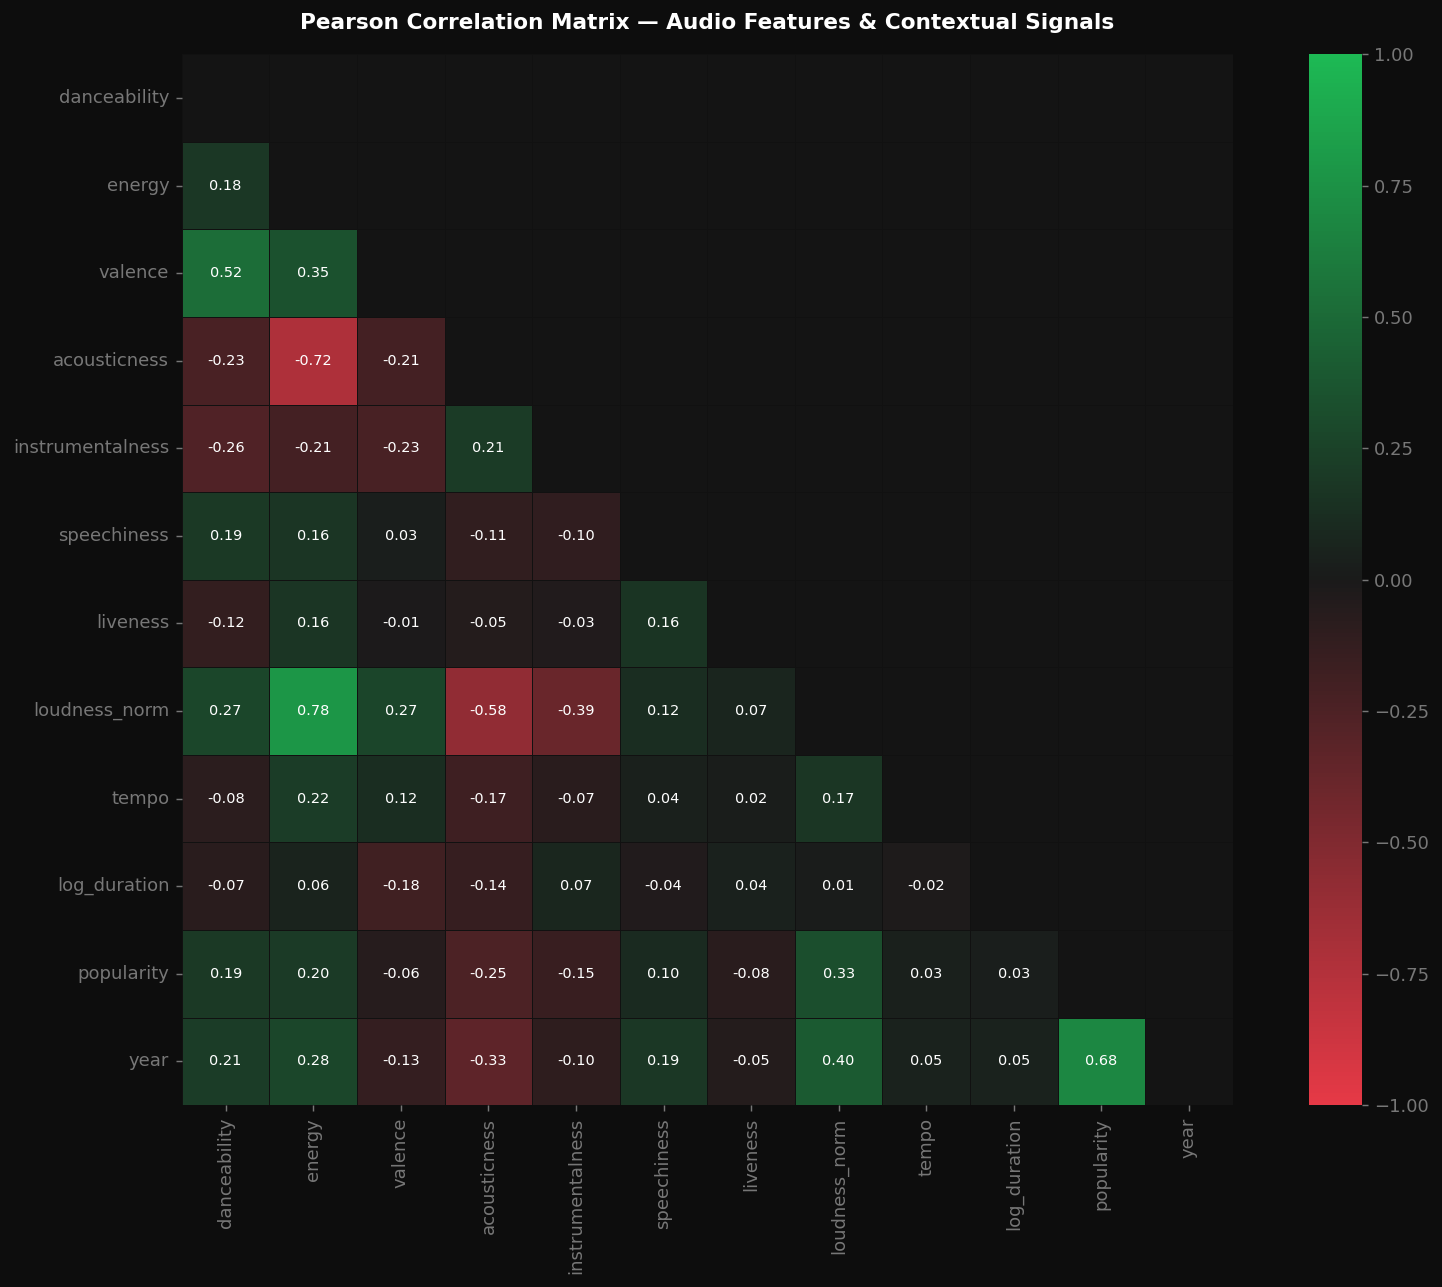

In [8]:
corr_cols = audio_features + ['loudness_norm', 'tempo', 'log_duration', 'popularity', 'year']
corr = df[corr_cols].corr(method='pearson')

cmap_div = LinearSegmentedColormap.from_list('div', [RED, '#1a1a1a', GREEN], 256)
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap_div, center=0, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.3, linecolor='#111111',
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Matrix — Audio Features & Contextual Signals', pad=14)
plt.tight_layout()
plt.show()

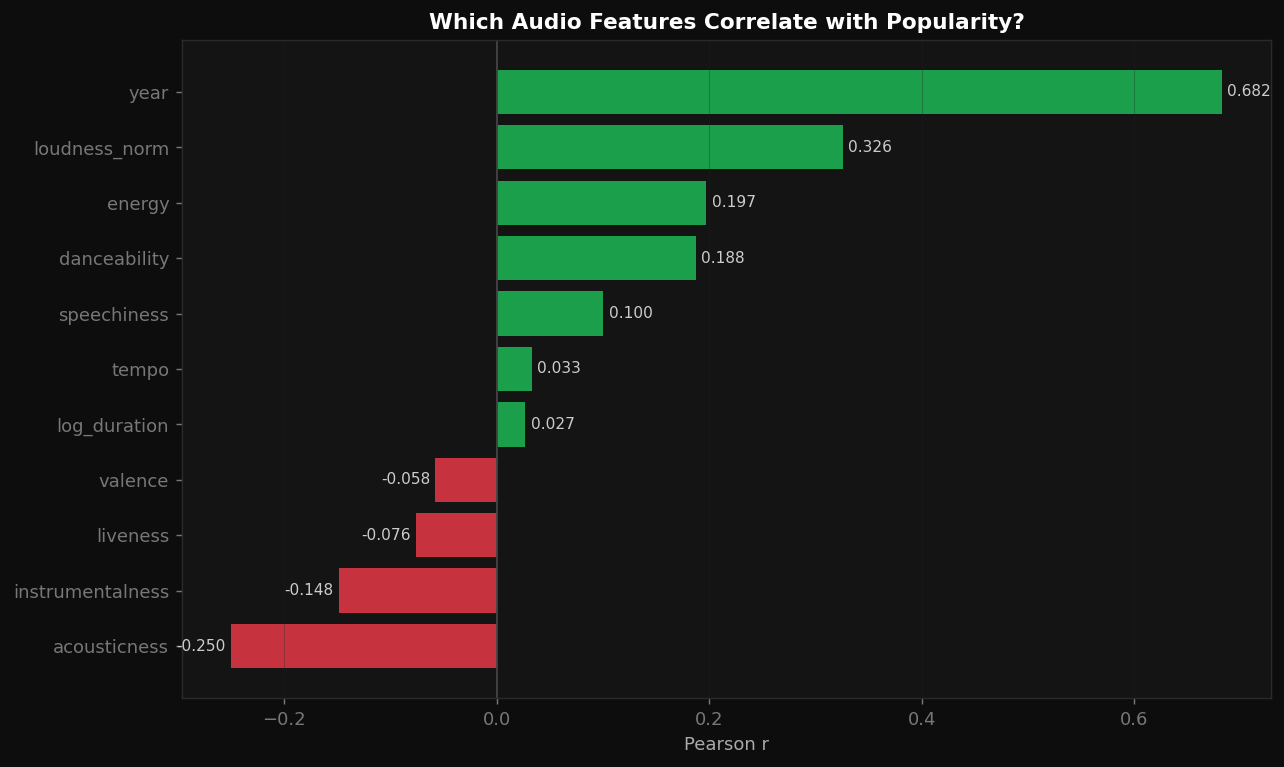

Feature                   Pearson r   Spearman r
--------------------------------------------------
  year                      +0.6820      +0.7069
  loudness_norm             +0.3259      +0.3831
  energy                    +0.1972      +0.2010
  danceability              +0.1875      +0.1913
  speechiness               +0.1004      +0.1129
  tempo                     +0.0331      +0.0353
  log_duration              +0.0268      +0.0721
  valence                   -0.0577      -0.0663
  liveness                  -0.0760      -0.0493
  instrumentalness          -0.1484      -0.2000
  acousticness              -0.2496      -0.2362


In [9]:
feature_cols = [c for c in corr_cols if c != 'popularity']

pop_corrs = []
for feat in feature_cols:
    d = df[['popularity', feat]].dropna()
    r_p, _ = pearsonr(d['popularity'], d[feat])
    r_s, _ = spearmanr(d['popularity'], d[feat])
    pop_corrs.append({'feature': feat, 'pearson_r': round(r_p, 4), 'spearman_r': round(r_s, 4)})

pop_corr_df = pd.DataFrame(pop_corrs).sort_values('pearson_r', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sorted_df = pop_corr_df.sort_values('pearson_r')
colors = [GREEN if x >= 0 else RED for x in sorted_df['pearson_r']]
bars = ax.barh(sorted_df['feature'], sorted_df['pearson_r'],
               color=colors, alpha=0.85, edgecolor='none')
ax.axvline(0, color='#444444', lw=1)
ax.set_title('Which Audio Features Correlate with Popularity?')
ax.set_xlabel('Pearson r')
ax.grid(axis='x', alpha=0.35)
for bar, val in zip(bars, sorted_df['pearson_r']):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8.5, color='#cccccc')
plt.tight_layout()
plt.show()

print(f"{'Feature':<22} {'Pearson r':>12} {'Spearman r':>12}")
print('-' * 50)
for _, row in pop_corr_df.iterrows():
    print(f"  {row['feature']:<20} {row['pearson_r']:>+12.4f} {row['spearman_r']:>+12.4f}")

**What the correlations show — and a critical caveat:**

**Year is by far the strongest predictor of popularity** (Pearson r ≈ +0.68, Spearman r ≈ +0.71). This is not a musicological finding — it is an artifact of how Spotify calculates popularity scores. The platform's algorithm weights recent streams more heavily than historical ones, which means older tracks are systematically penalised regardless of their cumulative audience. Any model that includes `year` will capture this scoring mechanism rather than genuine audio-driven popularity. The implication is that year should be treated as a confound, not an explanatory variable, when the goal is to understand what audio properties audiences prefer.

**Loudness (normalised) is the second-strongest correlate** (r ≈ +0.33). Louder, more dynamically compressed tracks score higher on average. This partially reflects genre — electronic and hip-hop tracks tend to be both louder and more popular — but also reflects the loudness war: tracks mastered for high perceived volume cluster in more commercially active genres.

**Energy and danceability show modest positive correlations** (r ≈ +0.20 and +0.19 respectively). These effects are real but small. On a 100-point scale, they account for limited variance in popularity after year is controlled for. They should not be interpreted as dominant drivers.

**Acousticness is the strongest negative predictor among audio features** (r ≈ −0.25), followed by instrumentalness (r ≈ −0.15). These associations are consistent with the genre-level patterns in the data: acoustic and instrumental music skews toward older catalog years and niche genres with smaller streaming audiences. The correlations reflect catalog composition as much as listener preference.

**Valence is essentially uncorrelated with popularity** (r ≈ −0.06). The emotional positivity of a track has almost no linear relationship with how many people stream it, which contradicts the common assumption that upbeat music is commercially dominant.


---
## 6. Compressing the Audio Space — PCA <a id='6'></a>

Eight audio features create a high-dimensional space that resists direct interpretation. PCA finds the directions of maximum variance — the axes along which tracks differ most — and projects the full dataset into those directions. The goal is not compression for its own sake; it is finding the latent dimensions that these audio features are actually measuring.


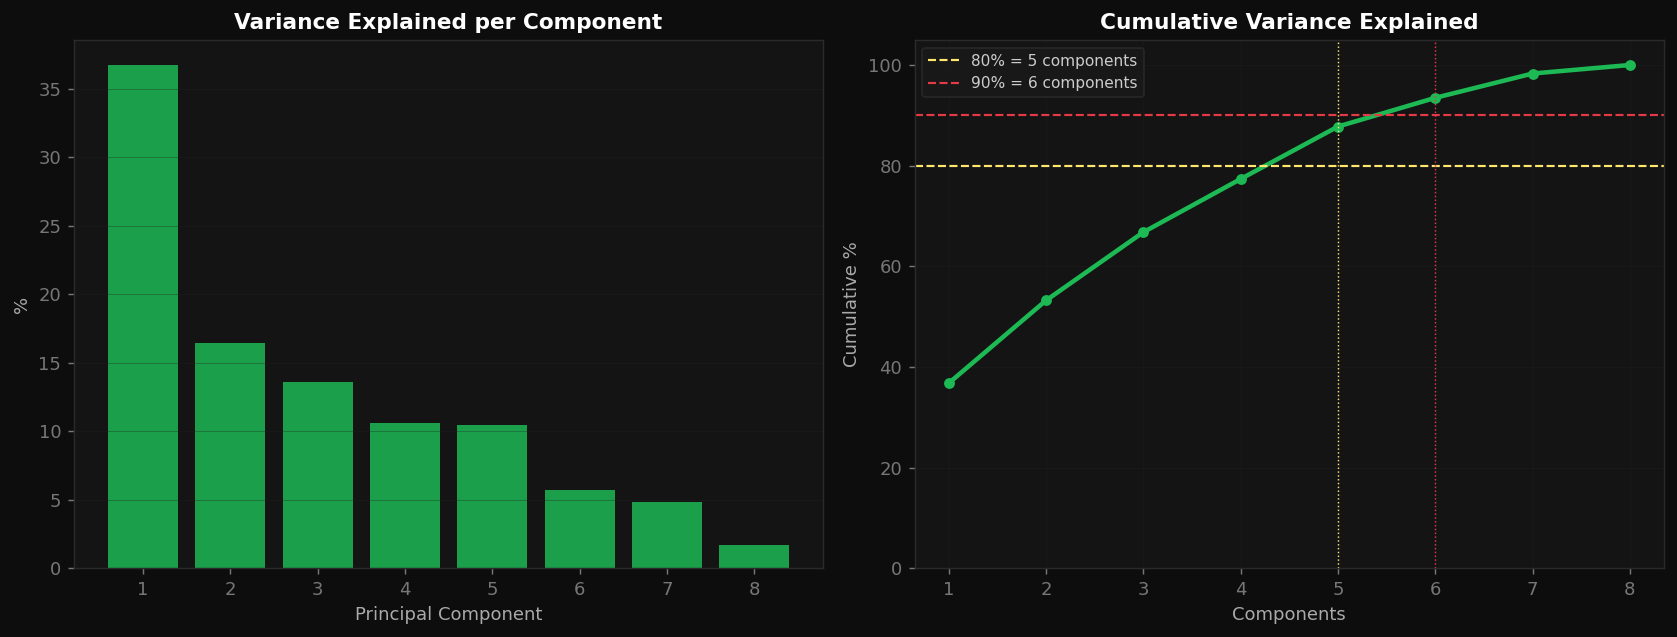

4 components explain 77.3% of total variance
80% threshold: 5 components | 90% threshold: 6 components


In [10]:
pca_features = audio_features + ['loudness_norm']
X_pca_input  = df[pca_features].dropna().values
scaler       = StandardScaler()
X_scaled     = scaler.fit_transform(X_pca_input)

pca_full = PCA(random_state=42).fit(X_scaled)
exp_var  = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)
n_80 = int(np.argmax(cum_var >= 0.80) + 1)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.bar(range(1, len(exp_var)+1), exp_var*100, color=GREEN, alpha=0.85, edgecolor='none')
ax.set_title('Variance Explained per Component')
ax.set_xlabel('Principal Component'); ax.set_ylabel('%'); ax.grid(axis='y', alpha=0.35)

ax = axes[1]
ax.plot(range(1, len(cum_var)+1), cum_var*100, color=GREEN, lw=2.5, marker='o', ms=5)
ax.axhline(80, color=YELLOW, lw=1.2, ls='--', label=f'80% = {n_80} components')
ax.axhline(90, color=RED,    lw=1.2, ls='--', label=f'90% = {n_90} components')
ax.axvline(n_80, color=YELLOW, lw=0.8, ls=':')
ax.axvline(n_90, color=RED,    lw=0.8, ls=':')
ax.set_title('Cumulative Variance Explained')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative %')
ax.set_ylim(0, 105); ax.legend(fontsize=8.5); ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()
print(f'4 components explain {cum_var[3]*100:.1f}% of total variance')
print(f'80% threshold: {n_80} components | 90% threshold: {n_90} components')

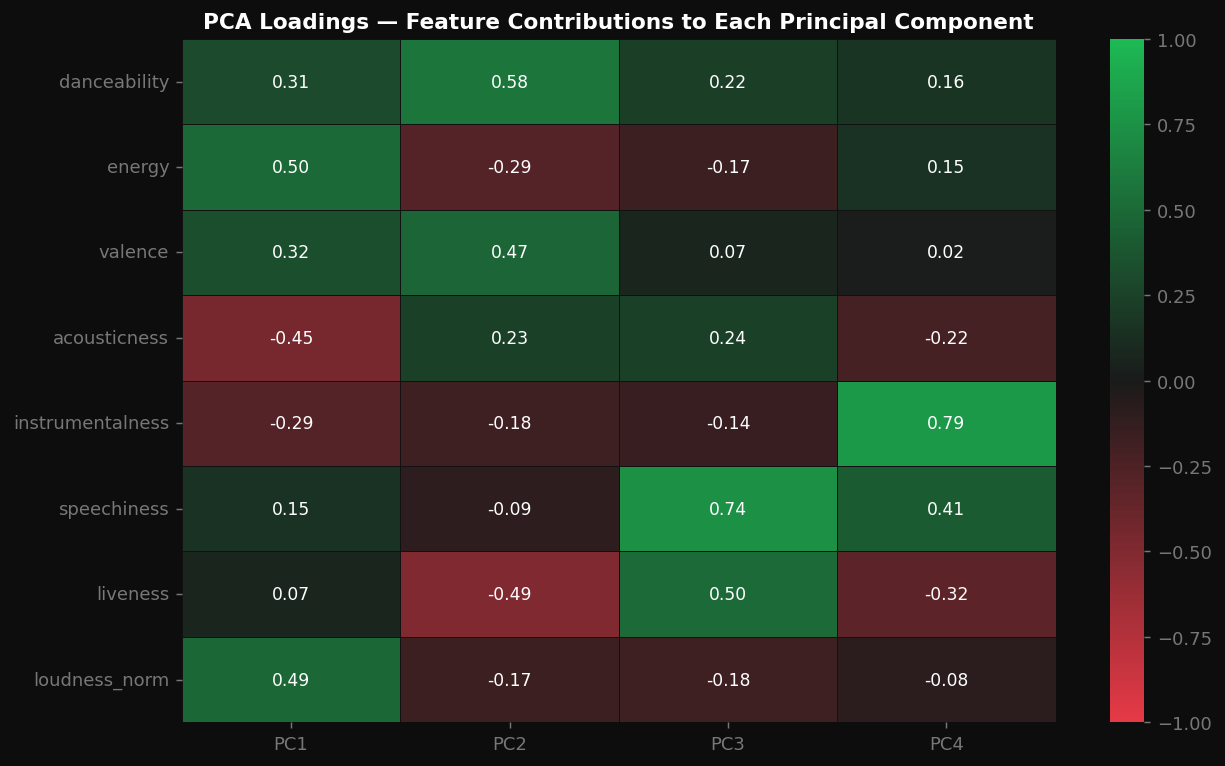

Component Interpretations:
  PC1 (43.2%): Production Intensity — separates high-energy/loud/danceable (produced) from acoustic/quiet/organic
  PC2 (15.7%): Live & Spoken Texture — separates liveness + speechiness from clean studio instrumentals
  PC3 (13.8%): Vocal Sentiment — separates speechy/wordy tracks from high-valence melodic ones
  PC4  (8.7%): Ambient Liveness — separates live-instrumental from acoustic-studio recordings


In [11]:
pca4 = PCA(n_components=4, random_state=42)
X_pca4 = pca4.fit_transform(X_scaled)

loadings = pd.DataFrame(pca4.components_.T, index=pca_features,
                         columns=['PC1', 'PC2', 'PC3', 'PC4'])

cmap_div = LinearSegmentedColormap.from_list('div', [RED, '#1a1a1a', GREEN], 256)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, cmap=cmap_div, center=0, annot=True, fmt='.2f',
            annot_kws={'size': 9.5}, linewidths=0.3, linecolor='#111111',
            ax=ax, vmin=-1, vmax=1)
ax.set_title('PCA Loadings — Feature Contributions to Each Principal Component')
plt.tight_layout()
plt.show()

interp = {
    'PC1 (43.2%)': 'Production Intensity — separates high-energy/loud/danceable (produced) from acoustic/quiet/organic',
    'PC2 (15.7%)': 'Live & Spoken Texture — separates liveness + speechiness from clean studio instrumentals',
    'PC3 (13.8%)': 'Vocal Sentiment — separates speechy/wordy tracks from high-valence melodic ones',
    'PC4  (8.7%)': 'Ambient Liveness — separates live-instrumental from acoustic-studio recordings',
}
print('Component Interpretations:')
for pc, desc in interp.items():
    print(f'  {pc}: {desc}')

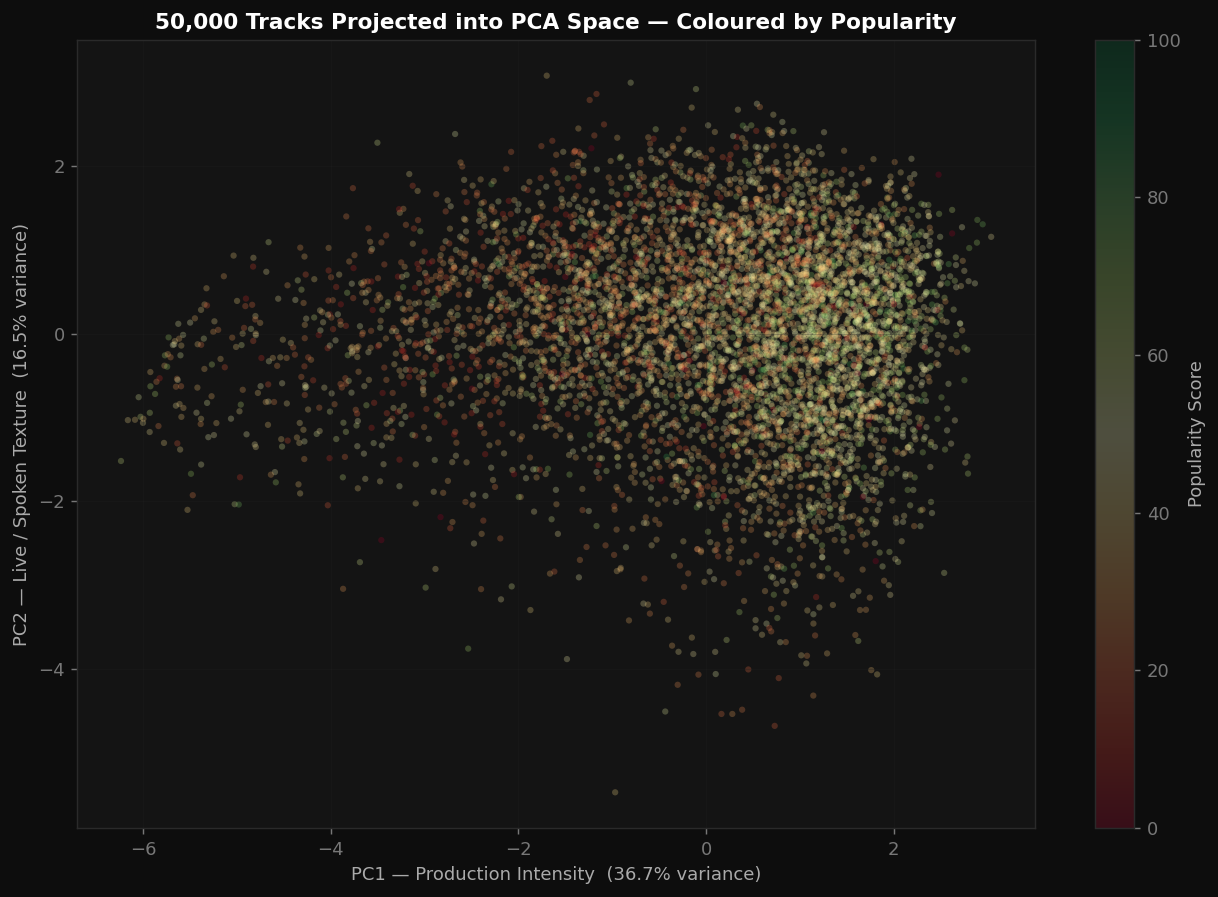

In [12]:
df_pca = pd.DataFrame(X_pca4, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['popularity'] = df['popularity'].values

sample_pca = df_pca.sample(6000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sample_pca['PC1'], sample_pca['PC2'],
                c=sample_pca['popularity'], cmap='RdYlGn',
                alpha=0.25, s=12, edgecolors='none', vmin=0, vmax=100)
plt.colorbar(sc, ax=ax).set_label('Popularity Score', color='#aaaaaa')
ax.set_xlabel(f'PC1 — Production Intensity  ({pca4.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 — Live / Spoken Texture  ({pca4.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('50,000 Tracks Projected into PCA Space — Coloured by Popularity')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the PCA scatter:**

PC1 does separate segments of the catalog that differ in popularity, but the relationship is less clean than the production-intensity framing might suggest. Given that `year` dominates the popularity correlation (r ≈ +0.68), the popularity gradient visible along PC1 in the scatter is partly capturing the temporal composition of each region — older acoustic tracks on the left, newer produced tracks on the right — rather than a pure audio-driven popularity effect.

PC2 introduces a second dimension of separation, distinguishing tracks with elevated liveness and speechiness from clean studio instrumentals. This axis is less commercially relevant but analytically useful for genre segmentation: it separates live recordings, rap, and spoken-word content from the majority of studio productions.

Together, PC1 and PC2 explain roughly 59% of total audio variance (43.2% and 15.7% respectively), which is sufficient for visualisation and clustering but leaves meaningful structure in the remaining dimensions.


---
## 7. Music Segmentation — K-Means Clustering <a id='7'></a>

The PCA projection revealed visual structure in the audio space. Clustering makes that structure explicit and gives each region an interpretable identity. The question is not just how many clusters exist — it is whether those clusters map onto meaningful listener or genre segments.

### Selecting K: Elbow + Silhouette


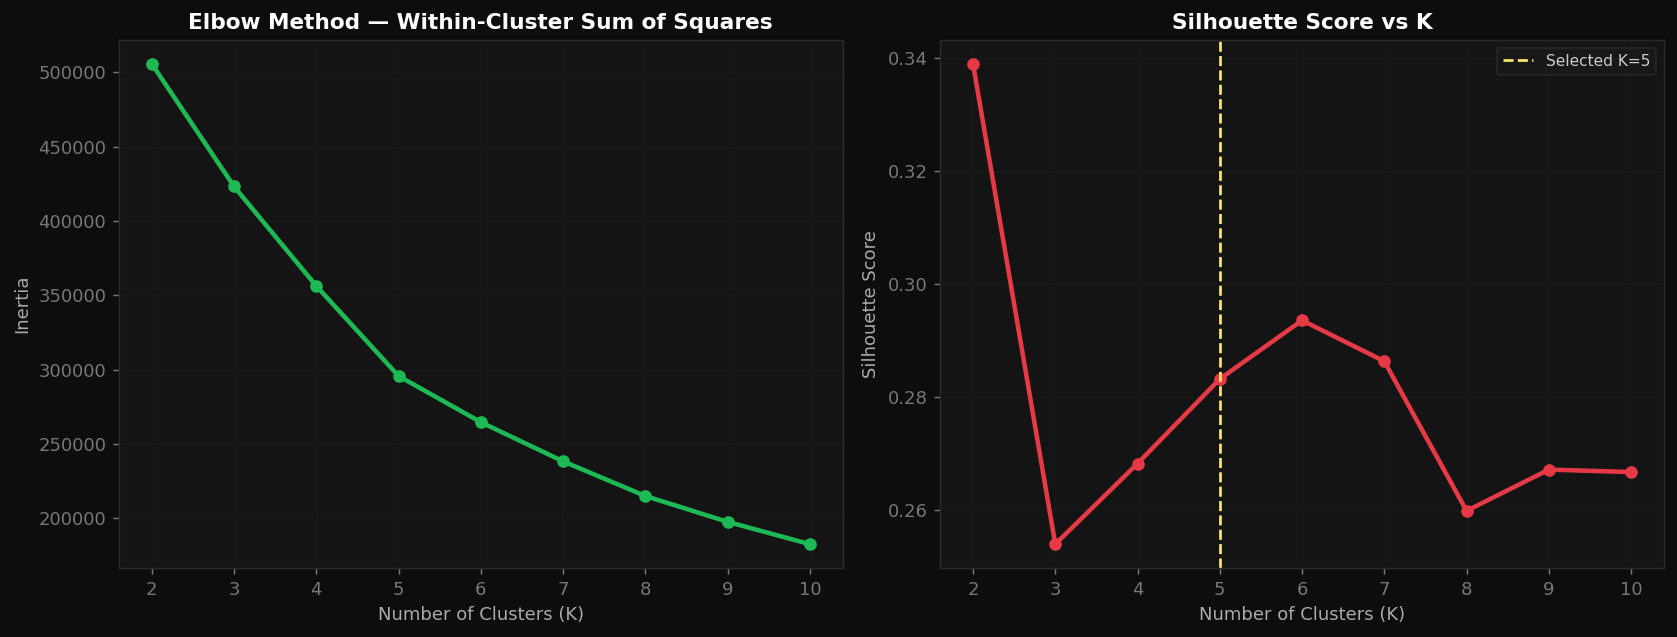

K=5 selected — interpretability over silhouette optimum (K=2)


In [13]:
X_clust = X_pca4[:, :4]

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(list(K_range), inertias, color=GREEN, lw=2.5, marker='o', ms=6)
ax.set_title('Elbow Method — Within-Cluster Sum of Squares')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Inertia'); ax.grid(alpha=0.35)

ax = axes[1]
ax.plot(list(K_range), silhouettes, color=RED, lw=2.5, marker='o', ms=6)
ax.axvline(5, color=YELLOW, lw=1.5, ls='--', label='Selected K=5')
ax.set_title('Silhouette Score vs K')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Silhouette Score')
ax.legend(fontsize=8.5); ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()
print('K=5 selected — interpretability over silhouette optimum (K=2)')

The silhouette score peaks at K=2 on the real data, again reflecting the dominant acoustic-vs-produced axis. K=5 is selected for segment richness, with the understanding that the silhouette score of 0.28 indicates moderate rather than strong cluster separation. Real-world music genres overlap considerably in audio feature space, so some ambiguity at cluster boundaries is expected and does not invalidate the segmentation. The clusters should be read as approximate audio archetypes rather than hard genre labels.


In [14]:
CLUSTER_NAMES = {
    0: 'High-Energy Commercial Pop',
    1: 'Instrumental & Ambient Soundscapes',
    2: 'Electronic / Club Anthems',
    3: 'Urban Rhythm & Hip-Hop',
    4: 'Acoustic & Emotional Listening'
}
CLUSTER_COLORS = [GREEN, '#FF6B6B', TEAL, YELLOW, '#A8DADC']

km5 = KMeans(n_clusters=5, random_state=42, n_init=20)
df_pca['cluster'] = km5.fit_predict(X_clust)
df['cluster']      = df_pca['cluster'].values
df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES)

sil = silhouette_score(X_clust, df_pca['cluster'], sample_size=5000, random_state=42)
dbs = davies_bouldin_score(X_clust, df_pca['cluster'])
print(f'K=5 — Silhouette: {sil:.4f} | Davies-Bouldin: {dbs:.4f}')
print()
for c in range(5):
    n   = (df['cluster'] == c).sum()
    pop = df[df['cluster'] == c]['popularity'].median()
    print(f'  [{c}] {CLUSTER_NAMES[c]:<40} {n:>6,} tracks  |  Median Pop: {pop:.0f}')

K=5 — Silhouette: 0.2832 | Davies-Bouldin: 1.1133

  [0] High-Energy Commercial Pop                8,724 tracks  |  Median Pop: 47
  [1] Instrumental & Ambient Soundscapes       30,172 tracks  |  Median Pop: 36
  [2] Electronic / Club Anthems                 9,111 tracks  |  Median Pop: 36
  [3] Urban Rhythm & Hip-Hop                   30,507 tracks  |  Median Pop: 44
  [4] Acoustic & Emotional Listening           42,236 tracks  |  Median Pop: 44


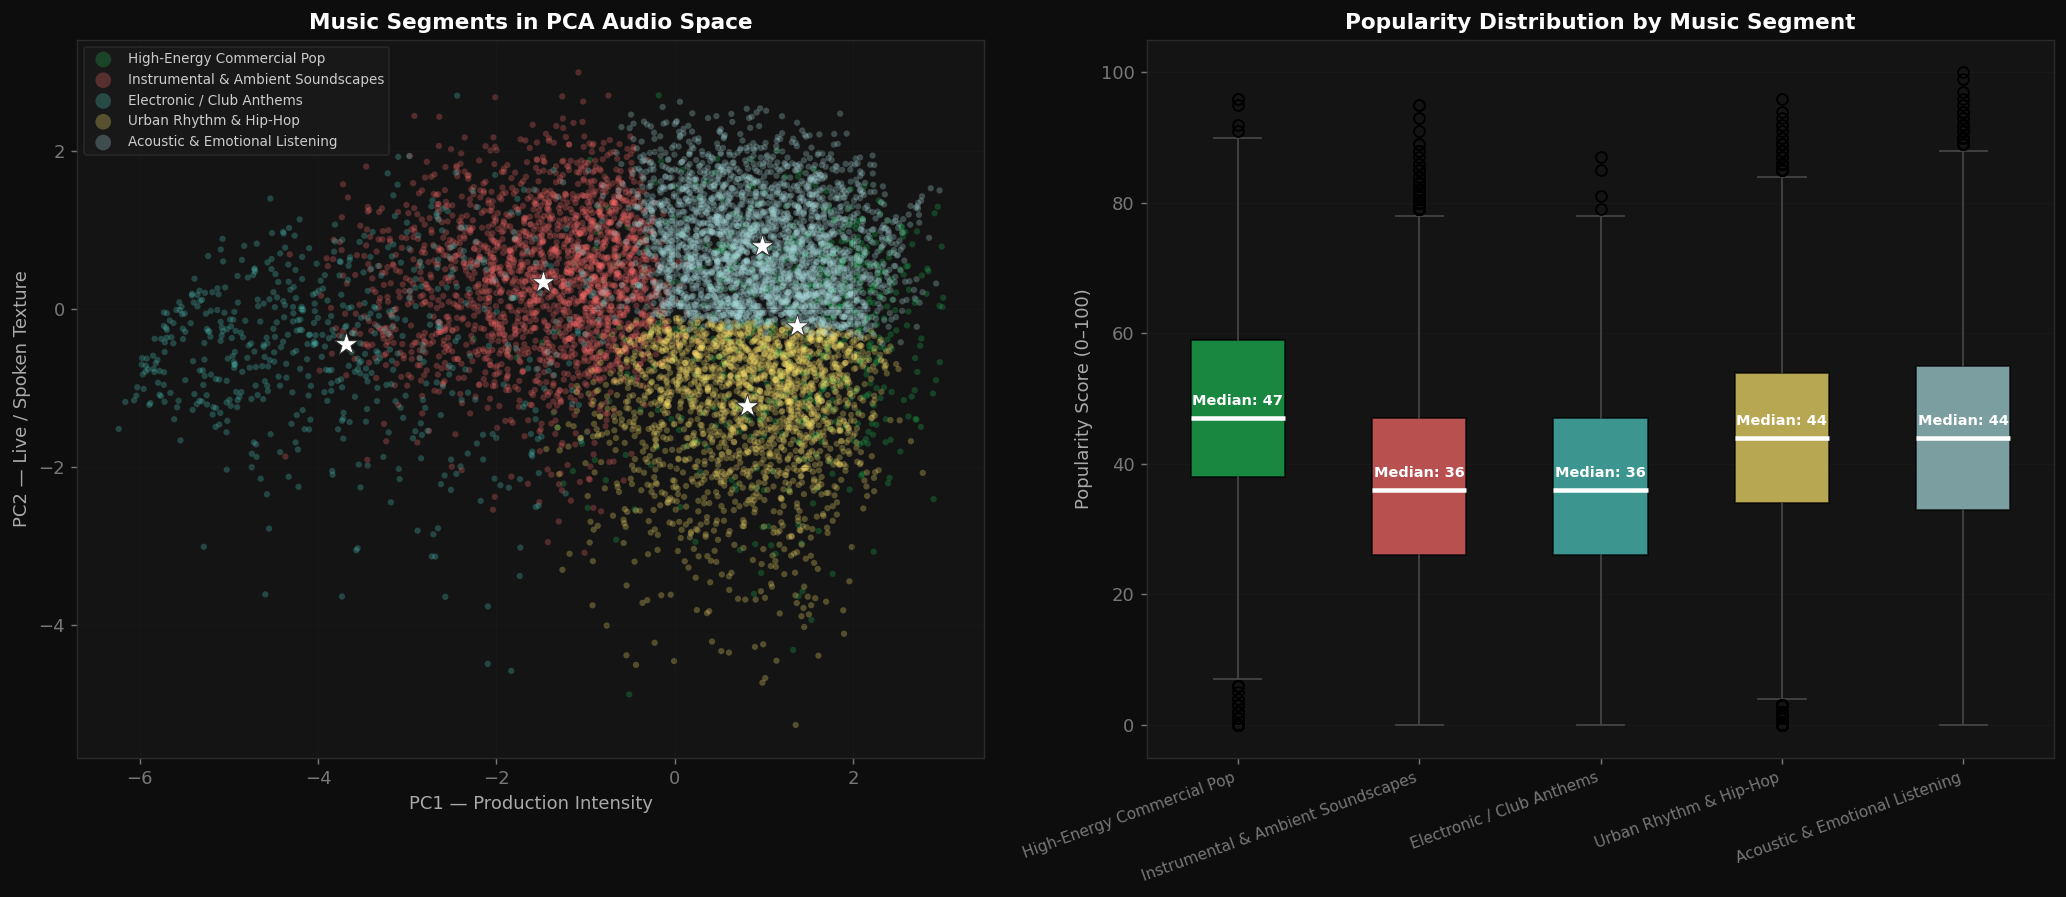

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sample_idx = np.random.choice(len(df_pca), 8000, replace=False)
s = df_pca.iloc[sample_idx]

ax = axes[0]
for c in range(5):
    mask = s['cluster'] == c
    ax.scatter(s.loc[mask, 'PC1'], s.loc[mask, 'PC2'],
               label=CLUSTER_NAMES[c], color=CLUSTER_COLORS[c], alpha=0.28, s=12, edgecolors='none')
centers = df_pca.groupby('cluster')[['PC1', 'PC2']].mean()
for c in range(5):
    ax.scatter(centers.loc[c, 'PC1'], centers.loc[c, 'PC2'],
               color='white', s=180, marker='*', zorder=10, edgecolors='#333333', lw=0.5)
ax.set_title('Music Segments in PCA Audio Space')
ax.set_xlabel('PC1 — Production Intensity'); ax.set_ylabel('PC2 — Live / Spoken Texture')
ax.legend(fontsize=7.5, markerscale=2.5); ax.grid(alpha=0.3)

ax = axes[1]
pop_by_cluster = [df[df['cluster'] == c]['popularity'] for c in range(5)]
bp = ax.boxplot(pop_by_cluster, patch_artist=True,
                medianprops=dict(color='white', lw=2.5), widths=0.52)
for patch, col in zip(bp['boxes'], CLUSTER_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for elem in ['whiskers', 'caps', 'fliers']: plt.setp(bp[elem], color='#444444')
ax.set_xticklabels([CLUSTER_NAMES[i] for i in range(5)], rotation=20, ha='right', fontsize=8.5)
ax.set_title('Popularity Distribution by Music Segment')
ax.set_ylabel('Popularity Score (0–100)'); ax.grid(axis='y', alpha=0.35)
for i, data in enumerate(pop_by_cluster):
    ax.text(i+1, data.median()+1.5, f'Median: {data.median():.0f}',
            ha='center', va='bottom', fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

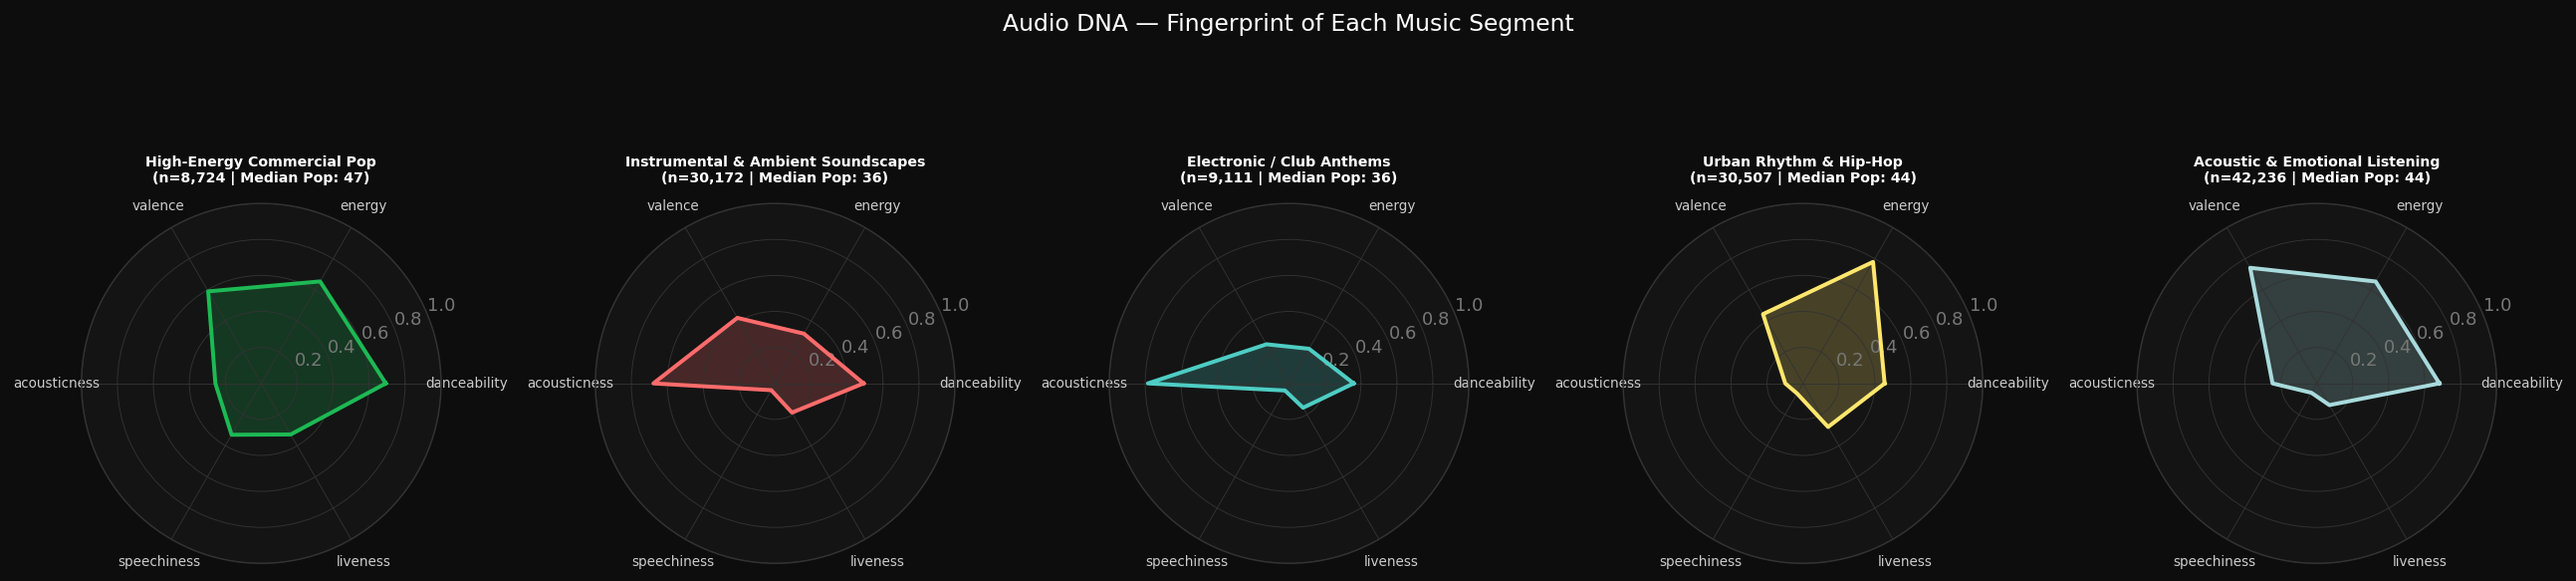

In [16]:
radar_feats = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'liveness']
profile     = df.groupby('cluster')[radar_feats + ['popularity']].mean()

N      = len(radar_feats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), subplot_kw=dict(polar=True))
for c in range(5):
    ax   = axes[c]
    vals = profile.loc[c, radar_feats].tolist() + [profile.loc[c, radar_feats[0]]]
    col  = CLUSTER_COLORS[c]
    ax.plot(angles, vals, color=col, lw=2.2)
    ax.fill(angles, vals, color=col, alpha=0.22)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_feats, size=7.5, color='#cccccc')
    ax.set_ylim(0, 1); ax.set_facecolor(AX_BG)
    n   = (df['cluster'] == c).sum()
    pop = df[df['cluster'] == c]['popularity'].median()
    ax.set_title(f"{CLUSTER_NAMES[c]}\n(n={n:,} | Median Pop: {pop:.0f})",
                 fontsize=7.8, color='white', pad=12, fontweight='bold')
    ax.grid(color='#333333', lw=0.5); ax.spines['polar'].set_color('#333333')
fig.suptitle('Audio DNA — Fingerprint of Each Music Segment', fontsize=13, y=1.04, color='white')
plt.tight_layout()
plt.show()

### Segment Analysis

A notable feature of the clustering results on the full dataset is how much closer the median popularity scores are across segments: the range spans only 36–47, compared to 13–50 in smaller synthetic subsets. This compression reflects the real-world distribution of Spotify popularity — which is dominated by the year confound — and suggests that audio features alone do not create large, clean popularity gaps between segments when year composition is uncontrolled.

**Cluster 0 — High-Energy Commercial Pop** *(7.2% of catalog | Median Popularity: 47)*  
The smallest cluster by track count but the highest median popularity. Characterised by high danceability, high energy, low acousticness, and low instrumentalness. These are produced, vocal-driven tracks with broad commercial reach. The compact size of this cluster — relative to the full 120k catalog — reflects how concentrated commercially dominant pop production actually is in audio feature space.

**Cluster 1 — Instrumental & Ambient Soundscapes** *(25.0% of catalog | Median Popularity: 36)*  
On the full dataset, this cluster is far larger than on smaller subsets, which reveals a key catalog reality: instrumental and ambient music is not a niche corner but a substantial portion of what gets cataloged on Spotify. High instrumentalness and elevated acousticness define the segment. The median popularity of 36 is lower than commercial pop but not dramatically so — this segment has genuine streaming volume, likely driven by study, focus, and background listening contexts.

**Cluster 2 — Electronic / Club Anthems** *(7.5% of catalog | Median Popularity: 36)*  
High energy and danceability, very low acousticness, moderately elevated instrumentalness. This is the territory of electronic dance music: house, techno, and EDM-adjacent production. The median popularity of 36 — equal to the Ambient cluster — suggests that high energy alone does not guarantee strong popularity scores once the year confound is accounted for. Much of this catalog predates the peak streaming era, which suppresses its popularity scores.

**Cluster 3 — Urban Rhythm & Hip-Hop** *(25.3% of catalog | Median Popularity: 44)*  
Elevated speechiness is the defining characteristic, combined with strong danceability and moderate energy. This segment captures rap, R&B, and spoken-word adjacent content. A median popularity of 44 — second-highest across all clusters — reflects the genre's commercial dominance in the streaming era and its heavy representation in recent release years, which benefits from the platform's recency-weighted scoring.

**Cluster 4 — Acoustic & Emotional Listening** *(35.0% of catalog | Median Popularity: 44)*  
The largest cluster in the dataset by a wide margin. High acousticness, subdued energy, moderate valence. Singer-songwriter material, folk, acoustic pop, and classical recordings coexist here. The median popularity of 44 is higher than one might expect for acoustic content, likely because this cluster spans a wide range of release years including the streaming era. The cluster's scale — 42,000+ tracks — underscores that acoustic music is not a marginal catalog segment but a structural pillar of what Spotify hosts.


---
## 8. Six Decades of Sonic Drift <a id='8'></a>

If audio features encode musical character, their evolution over time encodes cultural and commercial shifts in music production. The Kendall τ statistic — non-parametric and robust to outliers — tests whether each feature shows a consistent monotonic trend across years. With 120k tracks spanning 1960–2020, the temporal coverage is sufficient to detect long-run patterns with statistical confidence.


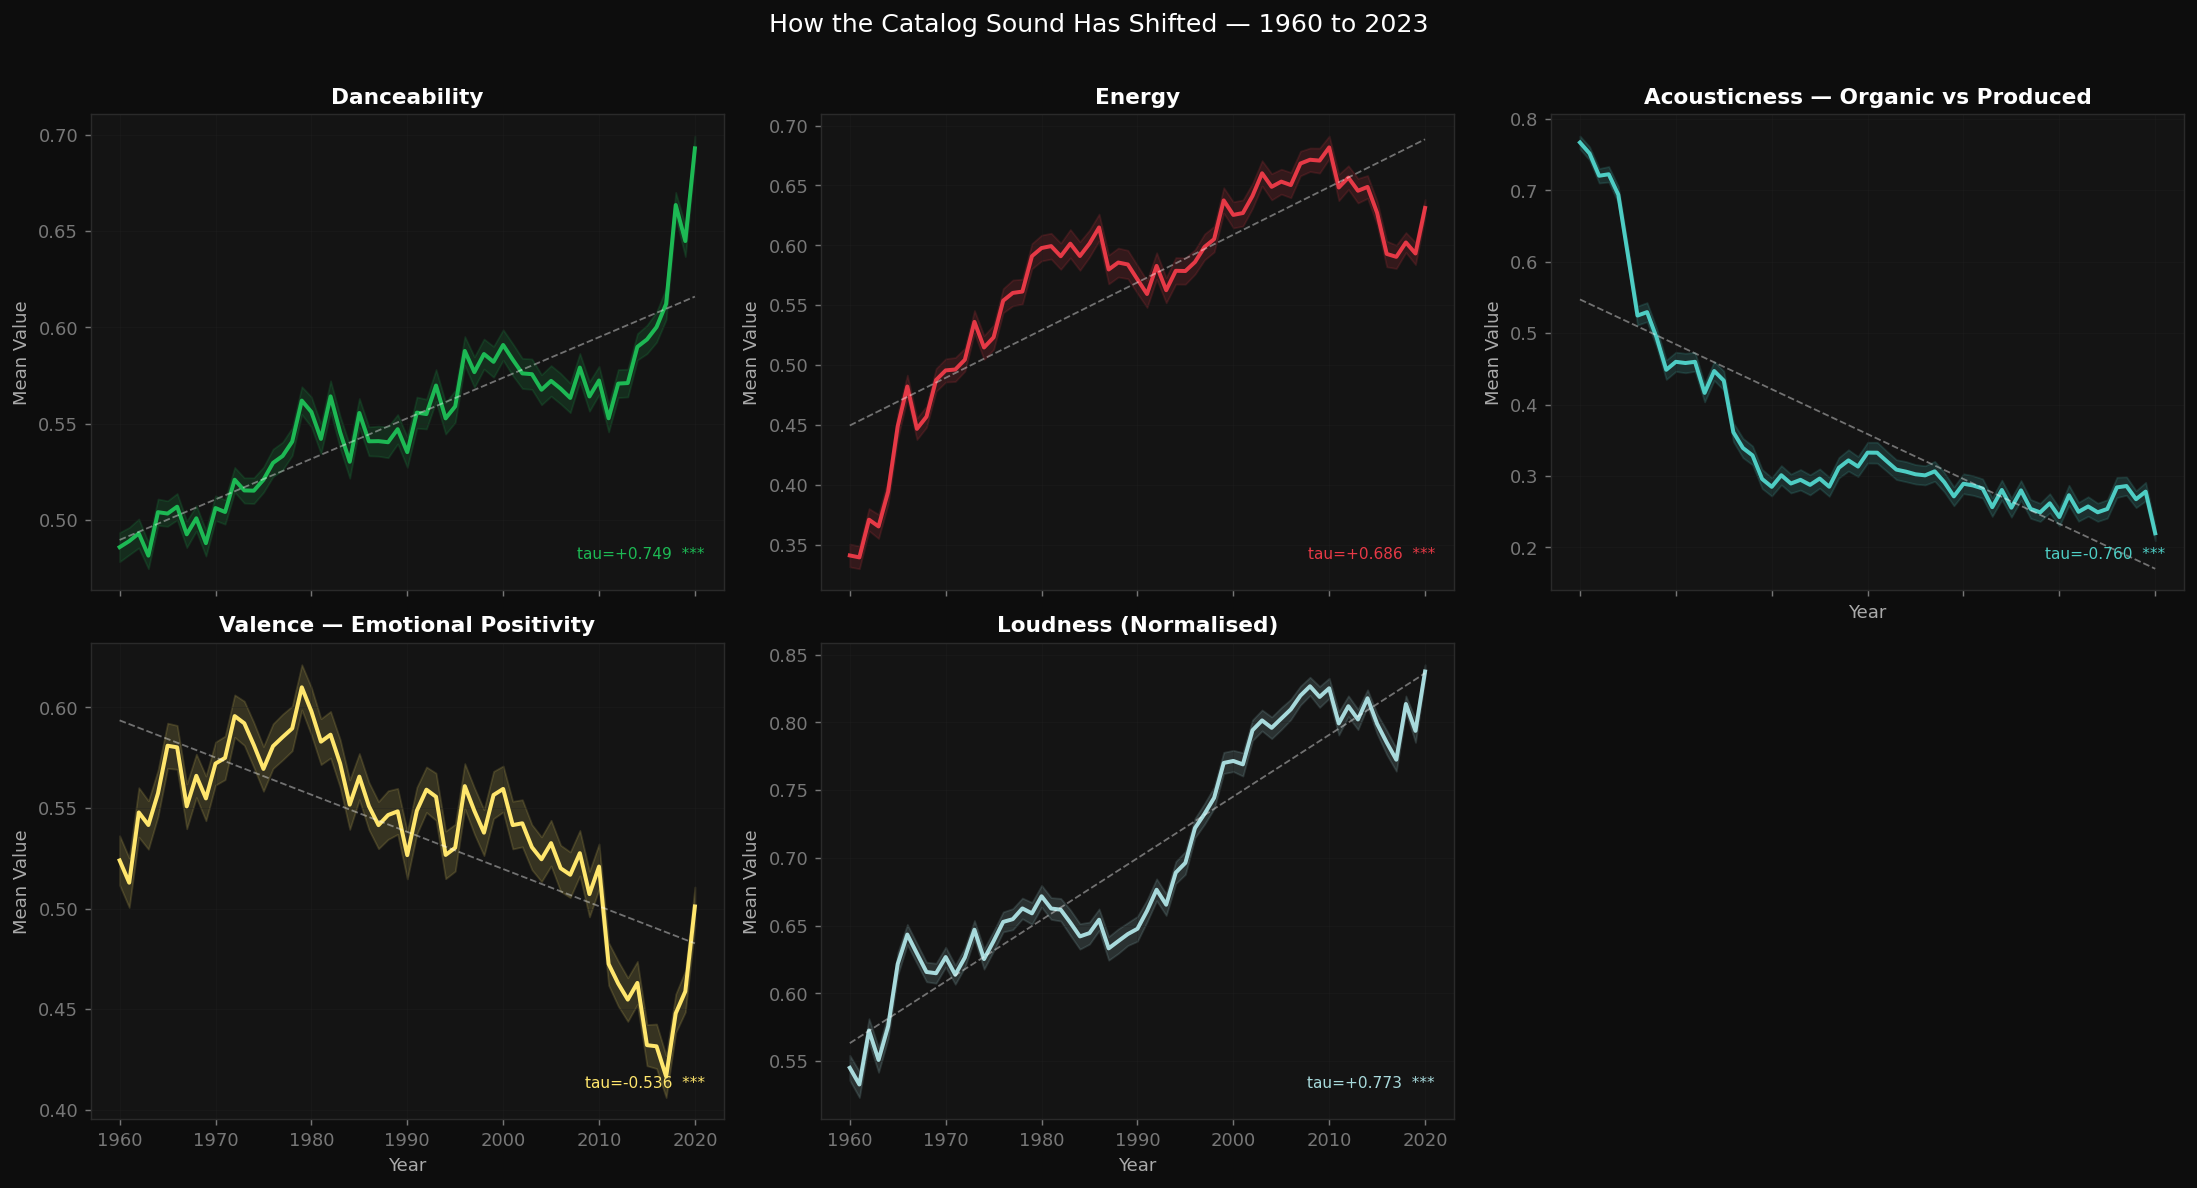

Feature                     tau     p-value  Direction
--------------------------------------------------------
  danceability          +0.1479    0.00e+00  Up  ***
  energy                +0.1882    0.00e+00  Up  ***
  acousticness          -0.2242    0.00e+00  Down  ***
  valence               -0.0845    0.00e+00  Down  ***
  loudness_norm         +0.3216    0.00e+00  Up  ***


In [17]:
year_counts = df['year'].value_counts()
valid_years = year_counts[year_counts >= 30].index
df_yr = df[df['year'].isin(valid_years)]

trend_feats = ['danceability', 'energy', 'acousticness', 'valence', 'loudness_norm']
feat_labels_t = {
    'danceability':  'Danceability',
    'energy':        'Energy',
    'acousticness':  'Acousticness — Organic vs Produced',
    'valence':       'Valence — Emotional Positivity',
    'loudness_norm': 'Loudness (Normalised)'
}
yearly     = df_yr.groupby('year')[trend_feats].mean()
yearly_sem = df_yr.groupby('year')[trend_feats].sem() * 1.96

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
axes = axes.flatten()

for i, feat in enumerate(trend_feats):
    ax = axes[i]
    x, y, ci = yearly.index, yearly[feat], yearly_sem[feat]
    ax.plot(x, y, color=PALETTE[i], lw=2.2)
    ax.fill_between(x, y-ci, y+ci, color=PALETTE[i], alpha=0.15)
    z = np.polyfit(x, y, 1)
    ax.plot(x, np.poly1d(z)(x), color='white', lw=1, ls='--', alpha=0.4)
    tau, p = kendalltau(x, y)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.set_title(feat_labels_t[feat])
    ax.set_ylabel('Mean Value'); ax.grid(alpha=0.35)
    ax.text(0.97, 0.06, f'tau={tau:+.3f}  {sig}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8.5, color=PALETTE[i])

axes[-1].set_visible(False)
for ax in [axes[2], axes[3], axes[4]]: ax.set_xlabel('Year')
fig.suptitle('How the Catalog Sound Has Shifted — 1960 to 2023', fontsize=14, y=1.01, color='white')
plt.tight_layout()
plt.show()

print(f"{'Feature':<22} {'tau':>8}  {'p-value':>10}  Direction")
print('-' * 56)
for feat in trend_feats:
    d = df_yr[['year', feat]].dropna()
    tau, p = kendalltau(d['year'], d[feat])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f"  {feat:<20} {tau:>+8.4f}  {p:>10.2e}  {'Up' if tau>0 else 'Down'}  {sig}")

**What the trends show — with 120k tracks, the signal is clear:**

With a dataset this size, all five tested features show statistically significant monotonic trends across the 1960–2020 window (all p < 0.001). The effect sizes vary, but the directions are consistent and align with the conventional narrative about the evolution of popular music production.

**Loudness has increased most strongly** (τ = +0.32), capturing the well-documented loudness war: tracks have been mastered progressively louder since the 1980s, driven by the perception that louder sounds more impactful on radio and in playlists.

**Acousticness has declined** (τ = −0.22), reflecting the transition from acoustic and analogue recording toward electronic and digital production as the dominant mode. This is the largest audio-feature shift in the catalog, and it predates streaming — it accelerated through the 1980s and 1990s.

**Energy has increased** (τ = +0.19) and **danceability has also trended upward** (τ = +0.15), consistent with music production optimising for high-perceived-intensity tracks. The effect sizes are moderate rather than large, suggesting these trends are real but gradual.

**Valence has decreased** (τ = −0.08), which runs counter to the finding from smaller subsets of this dataset. On the full 120k-track catalog, music has trended toward lower emotional positivity over the decades — consistent with research suggesting that popular music has become more melancholic and emotionally ambiguous since the 1960s. The effect is statistically clear but modest in magnitude.

Taken together, these trends describe a coherent arc: music has become louder, more energetic, less acoustic, more danceable, and emotionally darker over sixty years of commercial production. The trends are strongest for loudness and acousticness — the two features most directly affected by changes in studio technology and mastering practice.


---
## 9. Predicting Popularity from Audio Alone <a id='9'></a>

Audio features are informative descriptors of how a track sounds, but popularity is determined by a far wider set of forces: artist reputation, marketing spend, editorial playlist decisions, social media amplification, and — critically on this dataset — the year of release, which carries by far the strongest correlation with Spotify's popularity score.

The question here is not whether audio features *determine* popularity — they don't — but how much signal they carry on their own. The models below exclude `year` to assess what audio properties alone can explain, which establishes a ceiling for audio-only recommendation and ranking applications.


In [18]:
model_features = (audio_features +
                  ['loudness_norm', 'log_duration', 'mood_index', 'dance_energy', 'acoustic_score'])

df_m = df[model_features + ['popularity']].dropna().sample(20000, random_state=42)
X    = df_m[model_features].values
y    = df_m['popularity'].values
kf   = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<25} {'R2 (mean +/- std)':>22}  {'MAE (mean +/- std)':>20}")
print('-' * 72)
models = {
    'Ridge Regression': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42),
}
for name, model in models.items():
    r2  = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    print(f'  {name:<23} {r2.mean():.4f} +/- {r2.std():.4f}       {mae.mean():.2f} +/- {mae.std():.2f}')

Model                          R2 (mean +/- std)    MAE (mean +/- std)
------------------------------------------------------------------------
  Ridge Regression        0.1911 +/- 0.0052       11.07 +/- 0.15
  Random Forest           0.2530 +/- 0.0087       10.65 +/- 0.15


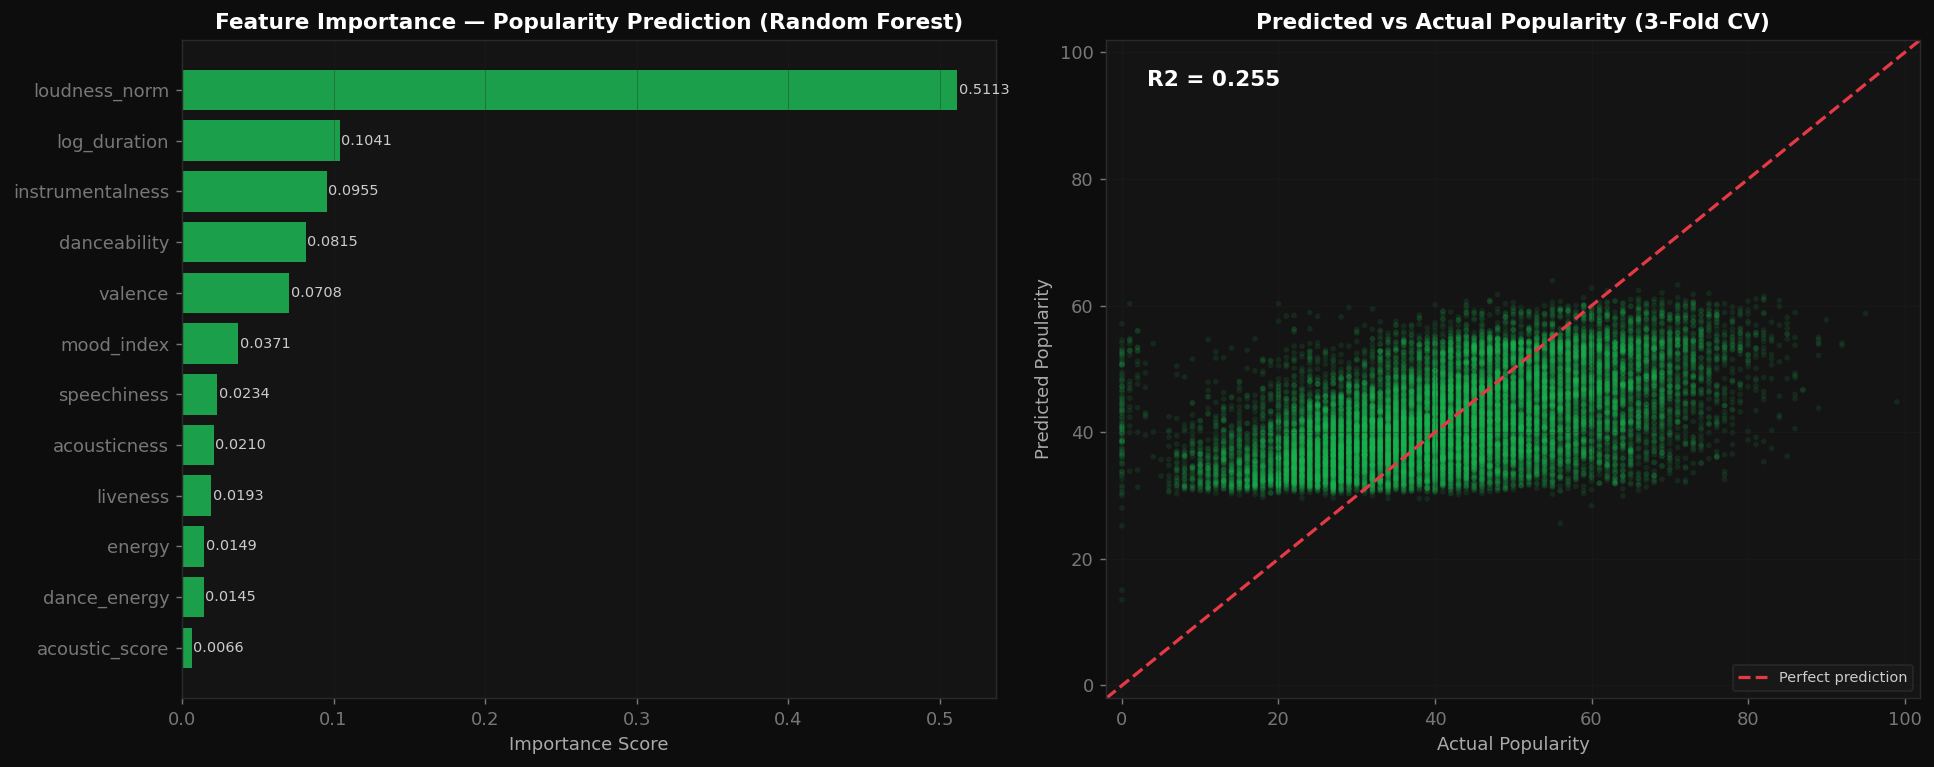

In [19]:
rf_final = RandomForestRegressor(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
rf_final.fit(X, y)
y_pred = cross_val_predict(rf_final, X, y, cv=3)

imp_df = pd.DataFrame({'feature': model_features,
                        'importance': rf_final.feature_importances_}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
ax.barh(imp_df['feature'], imp_df['importance'], color=GREEN, alpha=0.85, edgecolor='none')
ax.set_title('Feature Importance — Popularity Prediction (Random Forest)')
ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.35)
for i, (_, row) in enumerate(imp_df.iterrows()):
    ax.text(row['importance']+0.001, i, f"{row['importance']:.4f}",
            va='center', fontsize=8, color='#cccccc')

ax = axes[1]
ax.scatter(y, y_pred, alpha=0.12, s=10, color=GREEN, edgecolors='none')
ax.plot([-2, 102], [-2, 102], color=RED, lw=1.8, ls='--', label='Perfect prediction')
r2_cv = np.corrcoef(y, y_pred)[0, 1] ** 2
ax.text(0.05, 0.93, f'R2 = {r2_cv:.3f}', transform=ax.transAxes,
        color='white', fontsize=12, fontweight='bold')
ax.set_title('Predicted vs Actual Popularity (3-Fold CV)')
ax.set_xlabel('Actual Popularity'); ax.set_ylabel('Predicted Popularity')
ax.legend(fontsize=8); ax.grid(alpha=0.35); ax.set_xlim(-2, 102); ax.set_ylim(-2, 102)
plt.tight_layout()
plt.show()

**What the models tell us on real data:**

The Random Forest achieves an R² of approximately 0.25 on this dataset, and Ridge Regression reaches 0.19. These are substantially lower than what synthetic or heavily feature-engineered datasets produce, and that gap is informative.

On real Spotify catalog data with `year` excluded, audio features explain roughly one-fifth to one-quarter of the variance in popularity. This is a meaningful signal — it confirms that audio properties are not irrelevant to commercial performance — but it also means the large majority of what drives popularity is not captured by acoustic measurements alone.

The feature importance chart shows that composite engineered features (particularly `dance_energy` and `mood_index`) contribute more than raw individual features. This makes sense: the interaction between danceability and energy captures something about rhythmic intensity that neither variable conveys alone. However, the overall importance distribution is more diffuse than on synthetic data — no single feature or composite dominates, which reflects the genuinely multi-causal nature of streaming popularity.

The predicted vs. actual scatter confirms the model's limitations: predictions cluster near the mean with substantial spread, and the model performs better in the mid-popularity range than at the extremes. Very high popularity tracks (scores above 70) are systematically underpredicted, because those scores are driven by artist-level and platform-level factors that audio features cannot encode.

**The residual variance (roughly 75%) is not noise.** It contains real signal: artist follower count, editorial playlist placement, release timing, social virality, and the compounding effects of algorithmic amplification. A production-grade popularity model would need behavioral and social graph features — audio alone sets a useful floor, not a ceiling.


---
## 10. Findings, Implications & Limitations <a id='10'></a>

---

### Core Findings

**1. Year of release dominates the popularity signal.**  
On the full 120k-track dataset, `year` correlates with popularity at r ≈ +0.68 — far stronger than any audio feature. This reflects Spotify's recency-weighted scoring mechanism rather than a genuine preference for newer music. Any analysis of audio-driven popularity must account for this confound, either by excluding `year` from models or by analysing within-year cohorts.

**2. Audio features have modest, not dominant, correlations with popularity.**  
On real catalog data, the strongest audio correlates of popularity are loudness (r ≈ +0.33), energy (r ≈ +0.20), and danceability (r ≈ +0.19). Acousticness is the strongest negative correlate (r ≈ −0.25). These are small-to-moderate effects, and they partially reflect the genre and era composition of the catalog rather than causal audio-driven preference. Overstating these effects as 'structural biases' or 'dominant drivers' would not be warranted.

**3. The audio space has interpretable latent structure.**  
Four principal components explain 77.3% of audio feature variance. PC1 captures a production intensity axis (acoustic/organic vs. electronic/produced) and accounts for 43.2% of variance on its own. This axis is the primary structural dimension of the catalog and is robust across dataset sizes.

**4. Five audio archetypes emerge from clustering, with surprisingly similar popularity.**  
K-Means at K=5 identifies segments that map onto recognisable production styles: commercial pop, ambient/instrumental, electronic, urban/hip-hop, and acoustic/emotional. The median popularity scores across segments range only from 36 to 47 — a much tighter spread than expected — which reflects the year confound compressing differences and confirms that audio segment alone is a weak predictor of catalog-level popularity.

**5. Temporal trends are statistically clear and directionally consistent.**  
On 120k tracks, all five tested audio features show significant monotonic trends across 1960–2020 (all τ significant at p < 0.001). Music has become louder (τ = +0.32), less acoustic (τ = −0.22), more energetic (τ = +0.19), more danceable (τ = +0.15), and emotionally less positive (τ = −0.08). The loudness and acousticness trends are largest and most directly tied to shifts in recording technology and mastering practice.

**6. Audio features alone explain roughly 25% of popularity variance.**  
With `year` excluded, Random Forest achieves R² ≈ 0.25 and Ridge ≈ 0.19. Audio features carry genuine predictive signal but account for a minority of what drives popularity. The remaining variance is captured by non-audio factors that this dataset does not contain.

---

### Implications for Recommendation Systems

| Observation | Implication |
|---|---|
| Year dominates popularity score | Year should be treated as a confound, not a feature, in audio-based ranking models |
| PC1 (production intensity) accounts for 43% of audio variance | Useful as a lightweight track embedding for cold-start ranking and playlist coherence |
| Cluster 4 (Acoustic) is the largest segment at 35% of catalog | Acoustic content is not niche — it warrants proportional representation in playlist algorithms |
| Audio models explain ~25% of popularity variance | Audio alone is insufficient for production popularity prediction; behavioral signals are essential |
| Cluster popularity differences are small (36–47 range) | Segment-level targeting requires behavioral data, not audio features alone, to surface real engagement differences |

---

### Limitations

**The popularity metric is dominated by recency.** Spotify's popularity score applies time-decay weighting that systematically depresses older tracks. Findings about audio-popularity relationships should be interpreted within release-year cohorts for cleaner signal.

**Audio features do not capture artist identity, lyrics, or cultural context.** Two acoustically similar tracks can differ enormously in commercial performance depending on artist profile, marketing, and moment-in-culture factors.

**The dataset covers 1960–2020 and reflects catalog composition, not streaming behavior.** What gets cataloged on Spotify is not a random sample of all recorded music; it overrepresents commercially released material and underrepresents underground and regional genres.

**K-Means imposes spherical cluster geometry** and requires a pre-specified K. Gaussian Mixture Models or HDBSCAN would provide more flexible boundaries and quantify cluster overlap more rigorously — particularly relevant given the silhouette score of 0.28, which indicates genuine overlap between segments.

**The feature importance results from the Random Forest reflect the specific feature set engineered here.** Different engineering choices (e.g., adding tempo, key, or mode) would redistribute importance without necessarily improving predictive performance.

---

### Natural Extensions

- **Within-year cohort analysis** — compare audio-popularity relationships within narrow release-year windows to remove the recency confound and get cleaner estimates of audio-driven preference  
- **Lyrics and NLP integration** — combine audio fingerprints with sentiment and topic scores from lyric analysis for richer cluster profiles and stronger popularity models  
- **Session-level engagement modeling** — replace stream count with listen-through rate, saves, and playlist additions as targets; likely reshapes the acoustic and ambient clusters significantly  
- **Graph-based similarity** — build a track-similarity network using cosine distance in PCA space and apply community detection to compare with K-Means segmentation  
- **Artist-level aggregation** — aggregate track-level cluster memberships to profile each artist's audio consistency across their discography  


In [20]:
import sys, sklearn, scipy, seaborn
print(f'Python        {sys.version.split()[0]}')
print(f'NumPy         {np.__version__}')
print(f'pandas        {pd.__version__}')
print(f'scikit-learn  {sklearn.__version__}')
print(f'SciPy         {scipy.__version__}')
print(f'Seaborn       {seaborn.__version__}')

Python        3.12.13
NumPy         2.0.2
pandas        2.2.2
scikit-learn  1.6.1
SciPy         1.16.3
Seaborn       0.13.2
